<img src="https://github.com/milena-seismo/DSB-Unit-03/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Introduction to Simple Linear Regression

---

### About
An introduction to Linear Regression: what it is, how it works, and how to run a model using `scikit-learn`.

### Learning Objectives
- Describe modeling.
- Calculate mean squared error.
- State the assumptions of a linear regression model.
- Be able to interpret the coefficients of a linear regression model.
- Identify the difference between simple and multiple linear regression.
- Fit, generate predictions from, and evaluate a linear regression model in `sklearn`, and maybe in `statsmodels`.

### Notebook Guide

Part I. **Simple Linear Regression**
- Introduction to Modeling (see slides)
- Baseline Prediction
- OLS regression model in scikit-learn
- Interpreting SLR Model
- Assumptions of SLR Model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Part I: Simple Linear Regression

When you have 1 predictor variable you are doing _simple linear regression_.

## The Data
Data source: [here](https://www.rdocumentation.org/packages/fpp2/versions/2.3/topics/elecdemand)

The data consist of electricity demand for Victoria, Australia every half-hour in 2014. We have three columns:

* Total electricity demand (in gigawatts)
* Whether or not it is a workday (0/1)
* Temperature (Celsius)

In [2]:
elec = pd.read_csv('https://raw.githubusercontent.com/CharleyHananiaGA/DSB-Unit-03/refs/heads/main/data/elecdemand.csv')

In [3]:
elec.head()

,demand,workday,temp
0,3.914647,0,18.2
1,3.672550,0,17.9
2,3.497539,0,17.6
3,3.339145,0,16.8
4,3.204313,0,16.3


In [4]:
elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   demand   17520 non-null  float64
 1   workday  17520 non-null  int64  
 2   temp     17520 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 410.8 KB


In [9]:

elect_20 = elec[elec['temp'] >= 15]

In [ ]:
# For this exercise only, we'll limit our focus to only days in which it was at least 20 degrees Celsius (68 F)


In [32]:
print(elect_20)

         demand  workday  temp
13     3.229404        0  20.3
15     3.319818        0  21.3
16     3.431795        0  21.9
17     3.502329        0  22.8
18     3.577586        0  23.4
...         ...      ...   ...
17508  4.125988        1  22.3
17509  4.013263        1  20.9
17510  3.924593        1  20.3
17511  3.893868        1  20.3
17512  3.927753        1  20.3

[3900 rows x 3 columns]


In [11]:
# Plot temperature vs. demand, we chnged 20 to 15

print(elect_20.shape)

(9919, 3)


<Axes: xlabel='temp', ylabel='demand'>

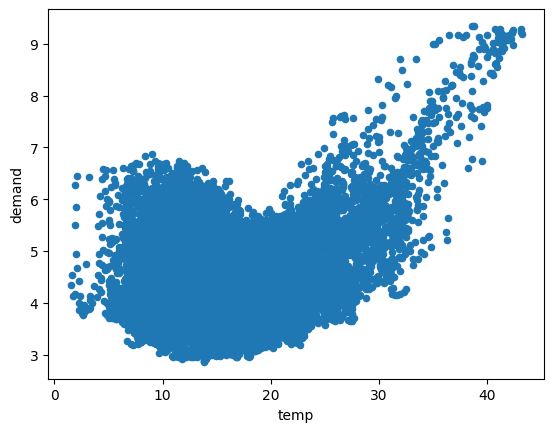

In [14]:
elec.plot(kind='scatter', x='temp', y='demand')

<Axes: xlabel='temp', ylabel='demand'>

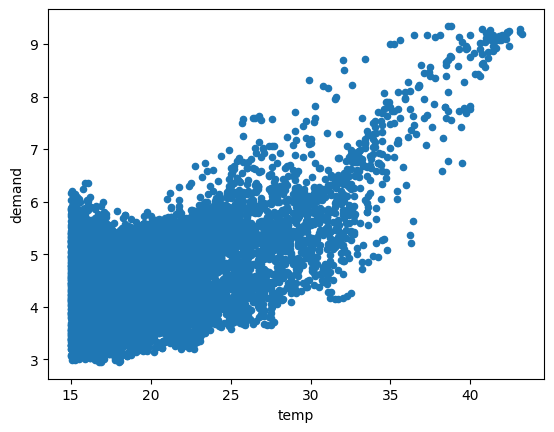

In [15]:
elect_20.plot(kind='scatter', x='temp', y='demand')

Text(0, 0.5, 'El.demand')

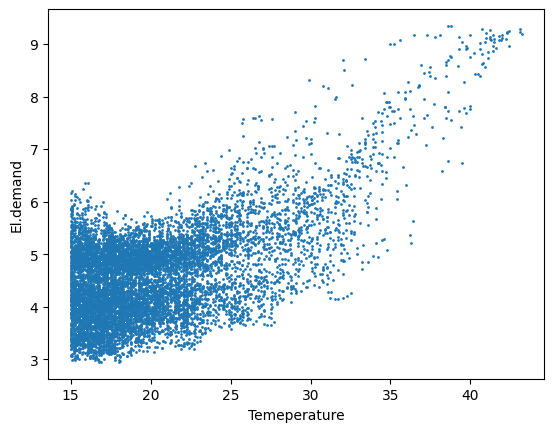

In [16]:
#matlotlib to show data

plt.scatter(elect_20['temp'], elect_20['demand'], s=1)
plt.xlabel('Temeperature')
plt.ylabel('El.demand')

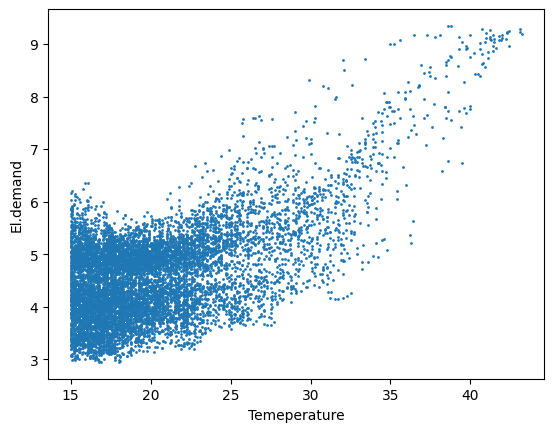

In [18]:
plt.scatter(elect_20['temp'], elect_20['demand'], s=1)
plt.xlabel('Temeperature')
plt.ylabel('El.demand')
plt.alpha=0.3

## The Null model

<details><summary>If we had to guess the demand for any new temperature what would you pick?</summary>
We don't have much information yet, so probably just the mean!
</details>

In [19]:
elect_20['demand'].mean()

np.float64(4.622494812629097)

## How could we improve our model?

<details><summary>If we were to draw a straight line that fit the points the best, what would that look like?</summary>
<img src="https://github.com/milena-seismo/DSB-Unit-03/blob/main/images/ols.png?raw=1", style="height: 350px">
</details>

ValueError: x and y must be the same size

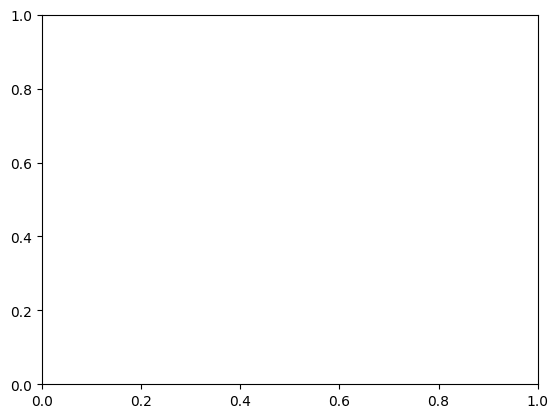

In [22]:
plt.scatter(elect_20["temp"], elec["demand"], s=1)
plt.axhline(elect_20['demand'].mean(), color = 'orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('El.demand')
plt.title('El.demand per half hour in 2014 vs Temperature outside; \nOnly showing >15C');

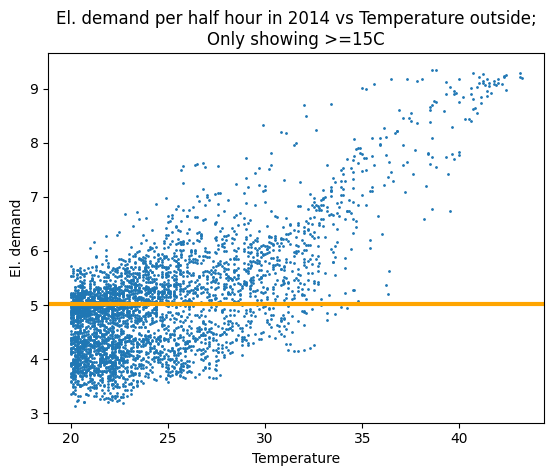

In [25]:
import matplotlib.pyplot as plt

elect_20 = elec[elec['temp'] >= 20]

plt.scatter(elect_20['temp'], elect_20['demand'], s=1)
plt.axhline(elect_20['demand'].mean(), color='orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('El. demand')
plt.title('El. demand per half hour in 2014 vs Temperature outside;\nOnly showing >=15C')
plt.show()

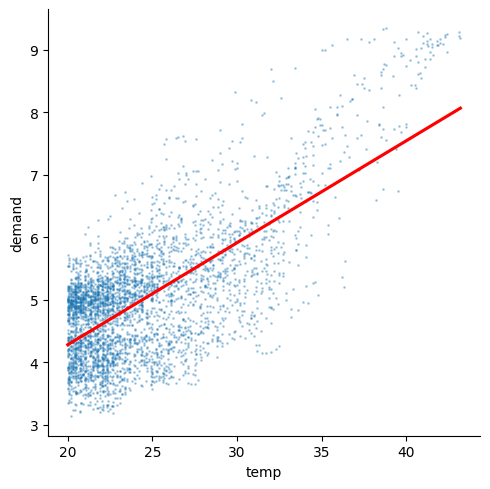

In [24]:
sns.lmplot(x='temp', y='demand', data=elect_20, ci=None,
           scatter_kws = {'s':1, 'alpha':0.3},
           line_kws={'color':'red'}
           );

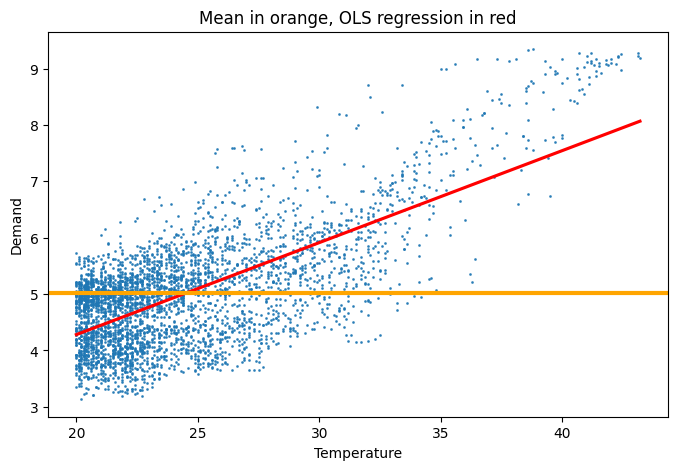

In [27]:
plt.figure(figsize = (8, 5))
sns.regplot(x='temp', y='demand', data=elect_20, ci=None,
            scatter_kws = {'s': 1},
            line_kws = {'color': 'red'})
plt.axhline(elect_20['demand'].mean(), color = 'orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('Demand')
plt.title('Mean in orange, OLS regression in red');

**Is that line better fit the data than our old line that was just the mean?**

Looks like it. We'll discuss formal evaluation metrics in a bit.

## Lines

This was the equation I learned for a line. Look familiar?
$$ y = mx + b$$
In data science it gets changed to

$$ y = \beta_0 + \beta_1 x_1 $$

### Errors

Our model isn't going to be perfect. The things our model doesn't capture are errors and denoted by $\epsilon$ (epsilon).

$$ y = \beta_0 + \beta_1 x_1 + \epsilon $$

### OLS Regression Modeling

We have _x_ and we have _y_. That's our data.

Our model is trying to figure out the best betas.

$$ \hat y = \hat \beta_0 + \hat \beta_1 x_1 $$


$\hat \beta_0$ is the y-intercept that our model learns. The point where the line crosses the y-axis.

$\hat \beta_1$ is the coefficient that we multiply by our $x_1$ variable. It's the slope. For every 1 unit it change in $x_1$, y increases by the value of $\beta1$.

$y$ is the ground truth of our target variable.


$$ \hat y =  \hat\beta_0 +  \hat\beta_1 x_1 $$

When we have a model that has been fit with the data the betas have been computed. We can plug in a new x value and solve for $\hat y$.

#### $\hat y$ is a prediction! 🎉

---
## OLS regression model in `scikit-learn`.

### Step 1: Assemble our predictor variables (X) and our target (y)

 We need an X matrix that is n-by-p.
- n = rows
- p = features

A feature just means a predictor column.

In the simple linear regression case, p = 1. We have one feature ($x_1$). Usually you'll have more than 1 feature.

In [28]:
# Step 1: Assemble our X and y variables

# We need an X matrix that is n-by-p (in this case, p = 1)
X = elect_20[['temp']]

In [29]:
type(X)

pandas.core.frame.DataFrame

#### Why did we make X a `DataFrame`?
`scikit-learn` expects a two dimensional object. Usually we have more than one predictor variable.

y is the outcome variable

In [34]:
# We need a y vector that is length n
y = elect_20['demand']

In [35]:
y.shape

(3900,)

#### Why is the target a `Series` or 1D numpy array?

`scikit-learn` supervised learning estimators are expecting a single output column. They predict one value for each observation, generally.

### Step 2: Instantiate the model

In [36]:
# Step 2: Instantiate the model
Ir = LinearRegression()

### Step 3: Fit the model

In [37]:
# Step 3: Fit the model
Ir.fit(X, y)

LinearRegression()

### Step 4: Check out and interpret our model weights

In [38]:
# Take a peek at the model coefficient and intercept
print(f'b0 is:{Ir.intercept_}')
print(f'b1 is:{Ir.coef_}')

b0 is:1.0168603310492106
b1 is:[0.16322116]


We now have the following model of reality:

$$\hat{d} = 2.32 + 0.11t$$

#### Interpretation of coefficients

In general, we can interpret our slope as having the following impact:
> For every 1 unit increase in $x_i$, we expect $y$ to increase by $\beta_i$.

<details><summary><font style = 'color:green'>How would we interpret the slope for our model?</font></summary>
For every 1 degree increase in temperature, we would expect 0.11 more gigawatts of electricty to be demanded.
</details>

#### Interpretation of our y-intercept. Does it make sense?

When it is zero degrees Celsius, we expect 2.32 gigawatts of electricity to be demanded. Ordinarily, this _would_ make sense, however, we have no data near this value (remember, we removed lots for the purpose of this exercse) and would want to avoid **extrapolation**.

### Step 5: Make predictions

If we had new data points for temperature we could pass it to the `predict` method to generate price predictions.

We don't have any new data, so let's just see what predictions our model would have made. This is the same as saying "Find the x value for a prediction on the plot and go up to our line. That value for y is our prediction."

We do this for all the x values.

In [40]:
# Make predictions
y_predict = Ir.predict(X)

In [41]:
type(y_predict)


numpy.ndarray

In [42]:
list(y_predict)

[np.float64(4.33024979632042),
 np.float64(4.49347095224511),
 np.float64(4.591403645799923),
 np.float64(4.738302686132146),
 np.float64(4.8362353796869595),
 np.float64(4.934168073241773),
 np.float64(5.032100766796588),
 np.float64(5.097389229166463),
 np.float64(5.260610385091153),
 np.float64(5.227966153906215),
 np.float64(5.14635557594387),
 np.float64(5.14635557594387),
 np.float64(4.885201726464366),
 np.float64(4.868879610871897),
 np.float64(4.591403645799923),
 np.float64(4.575081530207456),
 np.float64(4.852557495279428),
 np.float64(4.705658454947207),
 np.float64(4.721980570539676),
 np.float64(4.542437299022517),
 np.float64(4.80359114850202),
 np.float64(4.607725761392393),
 np.float64(4.6566921081698),
 np.float64(4.607725761392393),
 np.float64(4.6240478769848625),
 np.float64(4.64036999257733),
 np.float64(4.6240478769848625),
 np.float64(4.542437299022517),
 np.float64(4.346571911912889),
 np.float64(4.297605565135482),
 np.float64(4.31392768072795),
 np.float64(4.

In [43]:
np.set_printoptions(legacy='1.13')

In [44]:
list(Ir.predict(X))

[4.3302497963204196,
 4.4934709522451097,
 4.5914036457999234,
 4.7383026861321458,
 4.8362353796869595,
 4.9341680732417732,
 5.0321007667965878,
 5.0973892291664633,
 5.2606103850911534,
 5.2279661539062152,
 5.1463555759438702,
 5.1463555759438702,
 4.8852017264643663,
 4.8688796108718968,
 4.5914036457999234,
 4.5750815302074557,
 4.8525574952794281,
 4.7056584549472067,
 4.7219805705396762,
 4.5424372990225166,
 4.8035911485020204,
 4.607725761392393,
 4.6566921081697998,
 4.607725761392393,
 4.6240478769848625,
 4.6403699925773303,
 4.6240478769848625,
 4.5424372990225166,
 4.3465719119128892,
 4.2976055651354823,
 4.3139276807279501,
 4.3465719119128892,
 4.4118603742827656,
 4.4934709522451097,
 4.7056584549472067,
 4.7709469173170831,
 4.7056584549472067,
 4.395538258690296,
 4.3628940275053578,
 4.3465719119128892,
 4.5261151834300479,
 4.395538258690296,
 4.3302497963204196,
 4.3139276807279501,
 4.3302497963204196,
 4.3139276807279501,
 4.3302497963204196,
 4.36289402750535

#### Why don't we pass `y`?

We are predicting y.

In [46]:
elect_20['demand'].mean()

5.0215918354497431

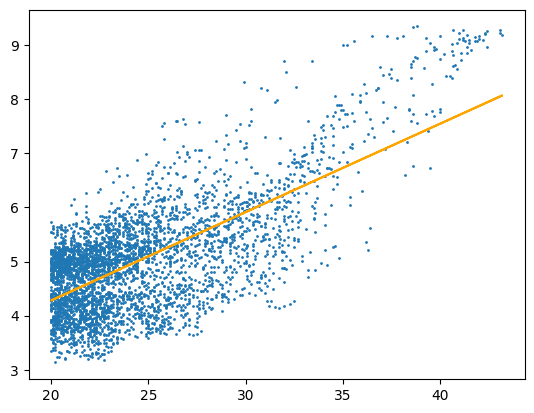

In [49]:
plt.scatter(elect_20['temp'], elect_20['demand'], s=1)
plt.plot(elect_20['temp'], y_predict, color='orange')
plt.show()

In [ ]:
# We can plot them, too!


---

To the slides!

---

### Step 6: Evaluation

We now want to see how good a job our model does at predicting demand. **Mean squared error** is a popular scoring metric.

Lower is better. That's the case whenever "error" is in the metric name.

$$ MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum e_i^2 $$

#### MSE by hand:

In [50]:
# Create residuals (aka errors): (y - y_hat)
residuals = y - y_predict
residuals

,demand
13,-1.100846
15,-1.173653
16,-1.159608
17,-1.235974
18,-1.258650
...,...
17508,-0.530704
17509,-0.414920
17510,-0.405656
17511,-0.436382


In [52]:
# Compute the MSE
mse = np.mean(residuals**2)
mse

0.53934367491525614

#### How does that model compare to our null model?

In [53]:
# Create the predictions for the "null model"
y_bar = y.mean()
y_bar

5.0215918354497431

In [54]:
# The null MSE
null_mse = np.mean((y-y_bar)**2)
null_mse

1.0425851018902454

<details><summary>Which model fits the data better?</summary>
The OLS model has lower error.
</details>

Another popular regression metric is the $R^2$, which is defined as:

$$R^2 = 1 - \frac{\text{SSE}}{\text{Null SSE}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

The $R^2$, or **coefficient of determination**, is the proportion of variability in $y$ we can explain with $x$.

In [55]:
# The R2 pokazuje u procentima koliko smo u pravu sa modelom
1-(mse / null_mse)

0.48268618654016249

#### Interpret $R^2$

35.2% of the variability in electricity demand can be explained by temperature.

We don't have to calculate these metrics by hand. `sklearn` can do it for us!

In [ ]:
# MSE


In [ ]:
# RMSE


In [ ]:
# Can compute R2 from metrics...


In [ ]:
# ... or directly from the model...


### You made your first Linear Regression Model 🎉

---

To the slides!

---

## LINE Assumptions
Let's check em!

In [ ]:
# L - Linearity


<details><summary>Does this pass our L assumption?</summary>
It's definitely a little curved, but this looks okay.
</details>

In [ ]:
# I - Independence

<details><summary>Does this pass our I assumption?</summary>
Yes, by assumption.
</details>

In [ ]:
# N - Normality of errors


<details><summary>Does this pass our N assumption?</summary>
Just like with the Linearity assumption, this isn't great, but we might be able to get away with it.
</details>

In [ ]:
# E - Equal variance of errors


<details><summary>Does this pass our E assumption?</summary>
I'm gonna go with no on this one...
</details>